In [7]:
# Import the required libraries.

import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Load the cleaned shipments dataset.

shipments = pd.read_csv("../Dataset/cleaned_shipments.csv")

In [9]:
# Display the first 5 records.

shipments.head()

,movement_id,shipment_id,container_id,customer_id,carrier_name,origin_port,origin_city,origin_country,destination_port,destination_city,...,container_type,cargo_type,shipment_value_usd,temperature_celsius,humidity_percent,delay_duration_hours,delay_penalty_rate_usd_per_hr,total_delay_penalty_usd,is_damaged,late_arrival_flag
0,MVT300001,SHP400000,CNT200001,CUST0079,Maersk,Port of Los Angeles,Los Angeles,US,Port of Dubai (Jebel Ali),Dubai,...,Reefer,Frozen Food,47709.85,-23.0,81.71,25.25,19.83,500.82,False,True
1,MVT300002,SHP400000,CNT200001,CUST0079,Maersk,Port of Los Angeles,Los Angeles,US,Port of Dubai (Jebel Ali),Dubai,...,Reefer,Frozen Food,58166.39,-23.0,81.71,13.70,22.78,312.09,False,True
2,MVT300004,SHP400000,CNT200001,CUST0079,Maersk,Port of Los Angeles,Los Angeles,US,Port of Dubai (Jebel Ali),Dubai,...,Reefer,Frozen Food,86482.24,-23.0,81.71,40.70,20.93,851.94,False,True
3,MVT300006,SHP400000,CNT200001,CUST0079,Maersk,Port of Los Angeles,Los Angeles,US,Port of Dubai (Jebel Ali),Dubai,...,Reefer,Frozen Food,88148.54,-23.0,81.71,20.85,21.17,441.44,False,True
4,MVT300007,SHP400000,CNT200001,CUST0079,Maersk,Port of Los Angeles,Los Angeles,US,Port of Dubai (Jebel Ali),Dubai,...,Reefer,Frozen Food,41482.11,-23.0,81.71,39.04,22.90,893.92,False,True


In [10]:
# Display dataset information.

shipments.info()

<class 'pandas.DataFrame'>
RangeIndex: 358990 entries, 0 to 358989
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   movement_id                    358990 non-null  str    
 1   shipment_id                    358990 non-null  str    
 2   container_id                   358990 non-null  str    
 3   customer_id                    358990 non-null  str    
 4   carrier_name                   358990 non-null  str    
 5   origin_port                    358990 non-null  str    
 6   origin_city                    358990 non-null  str    
 7   origin_country                 358990 non-null  str    
 8   destination_port               358990 non-null  str    
 9   destination_city               358990 non-null  str    
 10  destination_country            358990 non-null  str    
 11  departure_timestamp            358990 non-null  str    
 12  expected_arrival_timestamp     358990 non

status
arrived         117694
in_transit       96844
delayed          55608
departed         52858
customs_hold     35986
Name: count, dtype: int64


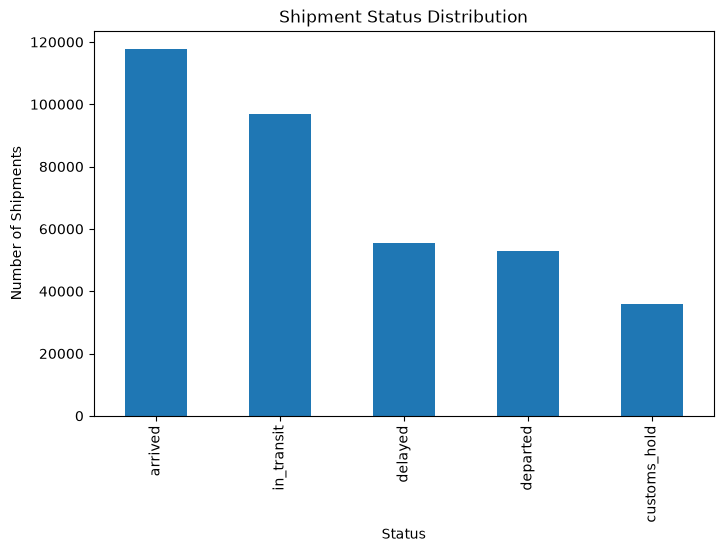

In [11]:
# Q1. What is the distribution of shipment statuses?

shipment_status = shipments["status"].value_counts()

print(shipment_status)

shipment_status.plot(kind="bar", figsize=(8,5))
plt.title("Shipment Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Shipments")
plt.show()

cargo_type
Electronics         56370
Frozen Food         55236
Textiles            50170
Chemicals           46871
Automotive Parts    43914
Machinery           43756
Furniture           35955
Pharmaceuticals     26718
Name: count, dtype: int64


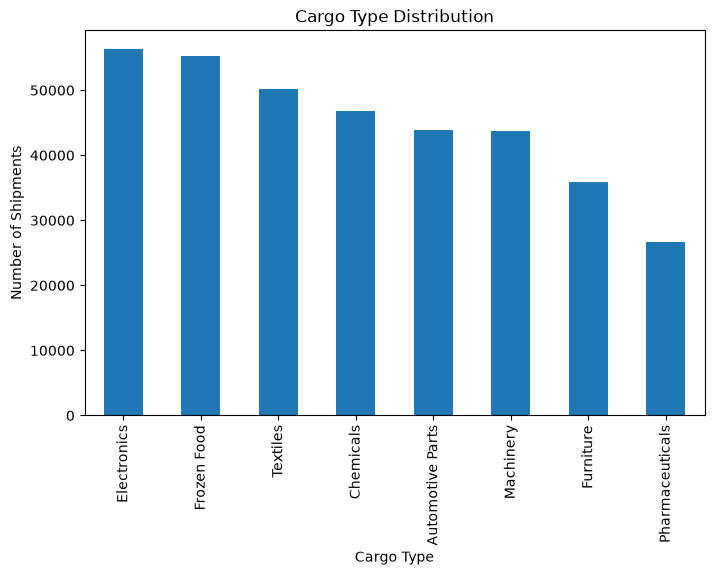

In [12]:
# Q2. Which cargo types are transported most frequently?

cargo_type = shipments["cargo_type"].value_counts()

print(cargo_type)

cargo_type.plot(kind="bar", figsize=(8,5))
plt.title("Cargo Type Distribution")
plt.xlabel("Cargo Type")
plt.ylabel("Number of Shipments")
plt.show()

carrier_name
Maersk         97752
MSC            76321
CMA CGM        63037
Hapag-Lloyd    45618
ONE            42673
Evergreen      33589
Name: count, dtype: int64


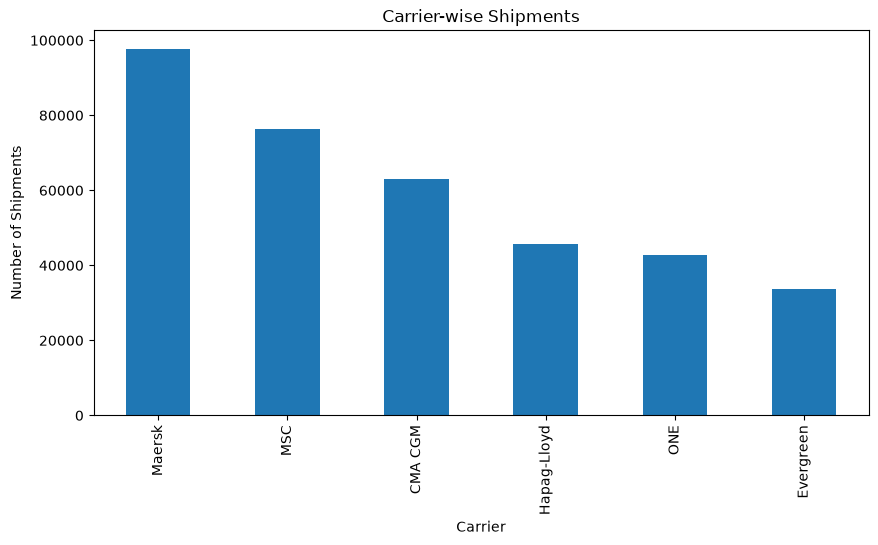

In [13]:
# Q3. Which carriers handle the highest number of shipments?

carrier = shipments["carrier_name"].value_counts()

print(carrier)

carrier.plot(kind="bar", figsize=(10,5))
plt.title("Carrier-wise Shipments")
plt.xlabel("Carrier")
plt.ylabel("Number of Shipments")
plt.show()

origin_country
CN    5.648741e+09
AE    4.655818e+09
SG    3.802162e+09
NL    3.097049e+09
DE    3.053548e+09
US    2.675857e+09
KR    2.586127e+09
Name: shipment_value_usd, dtype: float64


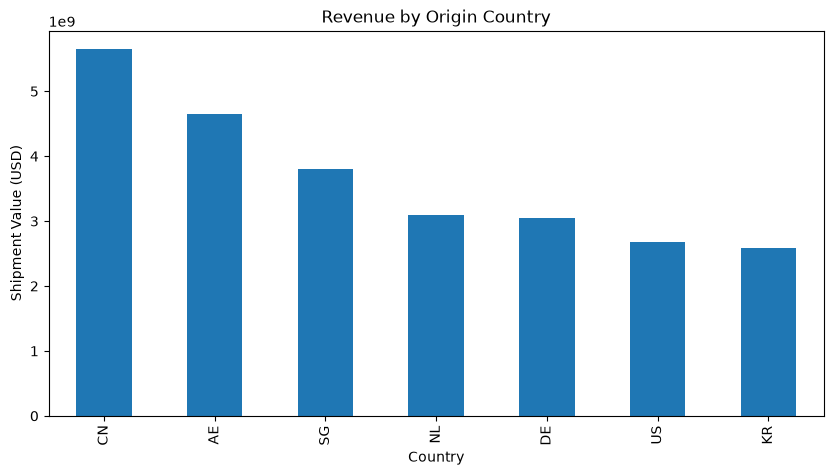

In [14]:
# Q4. Which countries generate the highest shipment value?

country_revenue = shipments.groupby("origin_country")["shipment_value_usd"].sum().sort_values(ascending=False)

print(country_revenue)

country_revenue.plot(kind="bar", figsize=(10,5))
plt.title("Revenue by Origin Country")
plt.xlabel("Country")
plt.ylabel("Shipment Value (USD)")
plt.show()

carrier_name
MSC            72884.813731
ONE            71506.278329
CMA CGM        71378.944984
Evergreen      70686.209347
Maersk         70027.652173
Hapag-Lloyd    69843.811780
Name: shipment_value_usd, dtype: float64


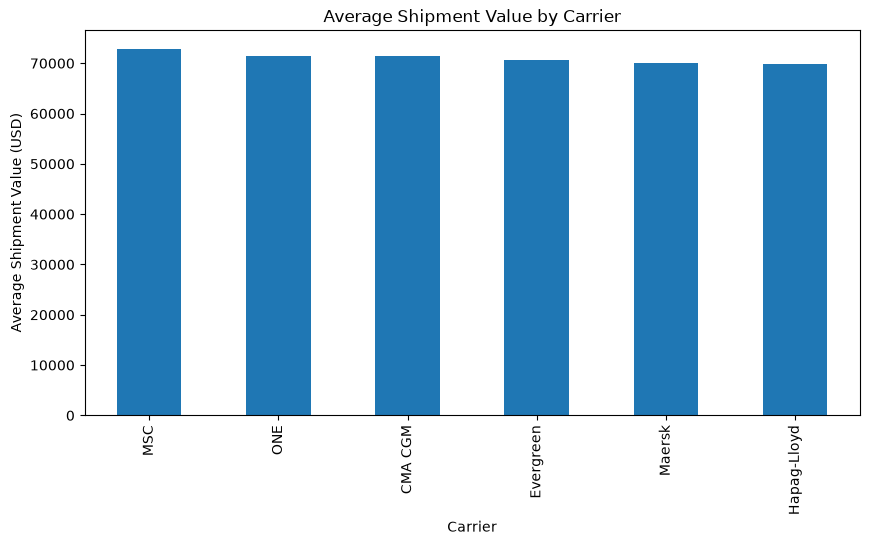

In [15]:
# Q5. What is the average shipment value by carrier?

avg_value = shipments.groupby("carrier_name")["shipment_value_usd"].mean().sort_values(ascending=False)

print(avg_value)

avg_value.plot(kind="bar", figsize=(10,5))
plt.title("Average Shipment Value by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Average Shipment Value (USD)")
plt.show()

late_arrival_flag
False    282476
True      76514
Name: count, dtype: int64


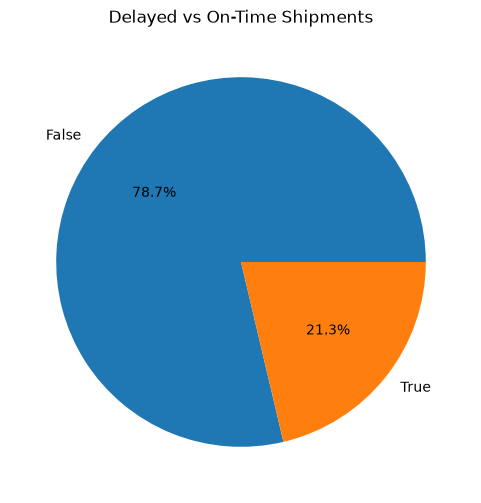

In [16]:
# Q6. What percentage of shipments were delayed?

delay = shipments["late_arrival_flag"].value_counts()

print(delay)

delay.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Delayed vs On-Time Shipments")
plt.ylabel("")
plt.show()

origin_port
Port of Shanghai (Yangshan)    77735
Port of Dubai (Jebel Ali)      64986
Port of Singapore              52428
Port of Rotterdam              44272
Port of Hamburg                43770
Port of Los Angeles            38507
Port of Busan                  37292
Name: count, dtype: int64


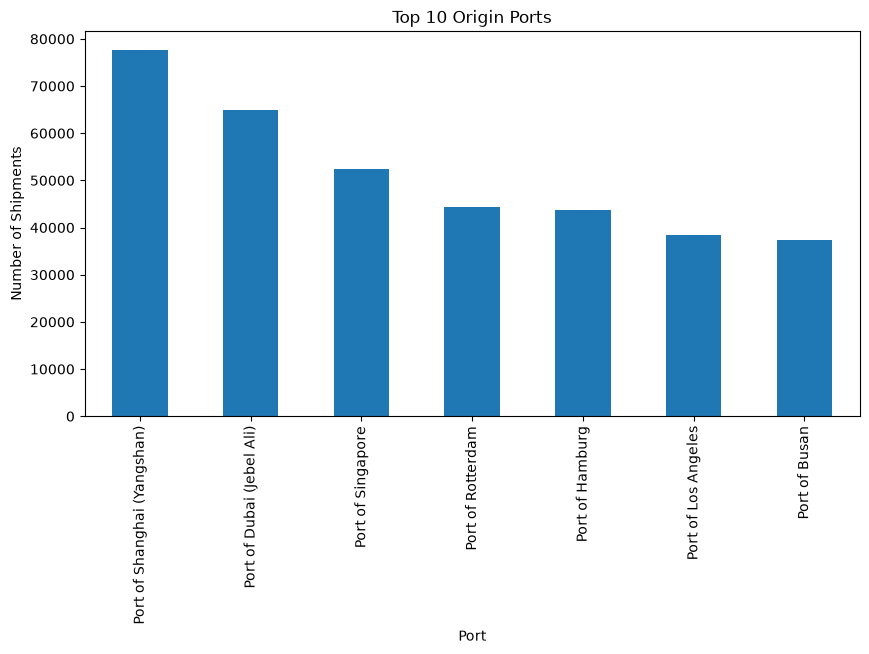

In [18]:
# Q7. Which ports handle the highest number of shipments?

ports = shipments["origin_port"].value_counts().head(10)

print(ports)

ports.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Origin Ports")
plt.xlabel("Port")
plt.ylabel("Number of Shipments")
plt.show()

container_type
40FT Standard     94317
40FT High Cube    92380
Reefer            81954
20FT Standard     53880
Open Top          36459
Name: count, dtype: int64


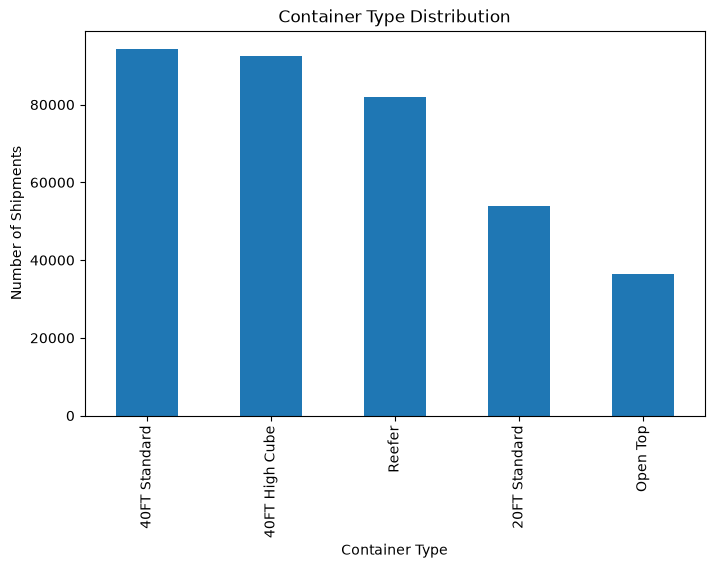

In [19]:
# Q9. Which container types are used most frequently?

container = shipments["container_type"].value_counts()

print(container)

container.plot(kind="bar", figsize=(8,5))
plt.title("Container Type Distribution")
plt.xlabel("Container Type")
plt.ylabel("Number of Shipments")
plt.show()

carrier_name
Maersk         6.845343e+09
MSC            5.562642e+09
CMA CGM        4.499515e+09
Hapag-Lloyd    3.186135e+09
ONE            3.051387e+09
Evergreen      2.374279e+09
Name: shipment_value_usd, dtype: float64


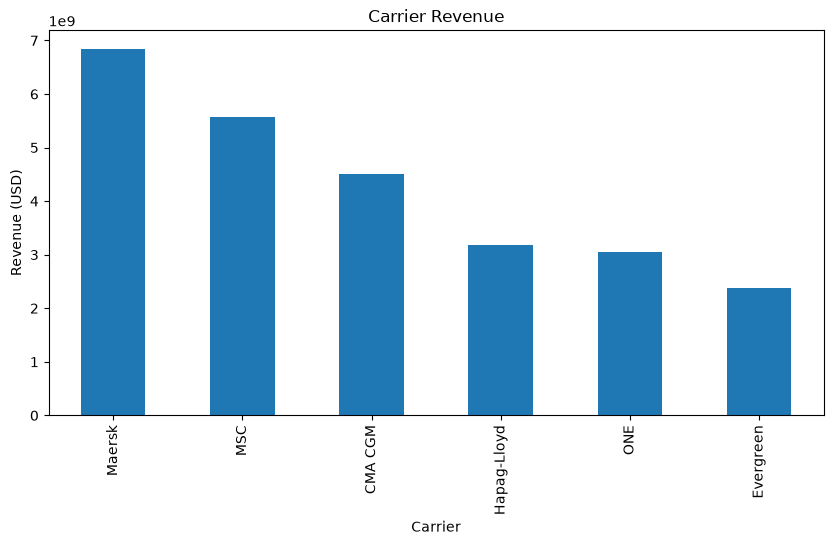

In [20]:
# Q10. Which carriers generate the highest shipment revenue?

carrier_revenue = shipments.groupby("carrier_name")["shipment_value_usd"].sum().sort_values(ascending=False)

print(carrier_revenue)

carrier_revenue.plot(kind="bar", figsize=(10,5))
plt.title("Carrier Revenue")
plt.xlabel("Carrier")
plt.ylabel("Revenue (USD)")
plt.show()